In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '125',
        '--data_nsample_exc', '420',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.7',

        '--lookback_nsample', '48',
        '--forecast_nsample', '24',

        '--batch_size', '32',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 8}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

>>> regime separator is computed as 0.5400000214576721


In [9]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.037901, valid=0.024722, test=0.017664
	validation loss decreased (inf -> 0.024722), saving model ...
	epoch 2 losses: train=0.025892, valid=0.018265, test=0.061807
	validation loss decreased (0.024722 -> 0.018265), saving model ...
	epoch 3 losses: train=0.027044, valid=0.022634, test=0.058320
	early stopping counter: 1 out of 30
	epoch 4 losses: train=0.020269, valid=0.014863, test=0.033863
	validation loss decreased (0.018265 -> 0.014863), saving model ...
	epoch 5 losses: train=0.012310, valid=0.010997, test=0.019629
	validation loss decreased (0.014863 -> 0.010997), saving model ...
	epoch 6 losses: train=0.010457, valid=0.008639, test=0.014105
	validation loss decreased (0.010997 -> 0.008639), saving model ...
	epoch 7 losses: train=0.009411, valid=0.007041, test=0.010693
	validation loss decreased (0.008639 -> 0.007041), saving model ...
	epoch 8 losses: train=0.006899, valid=0.007077, test=0.010760
	early stopping counter: 1

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

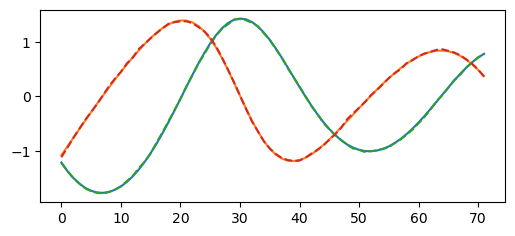

NameError: name 'tata' is not defined

In [11]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

print(tata.shape)

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.172211, valid=0.206912, test=0.212467
	validation loss decreased (inf -> 0.206912), saving model ...
	epoch 2 losses: train=0.169511, valid=0.193914, test=0.200251
	validation loss decreased (0.206912 -> 0.193914), saving model ...
	epoch 3 losses: train=0.179862, valid=0.188031, test=0.190400
	validation loss decreased (0.193914 -> 0.188031), saving model ...
	epoch 4 losses: train=0.198826, valid=0.180431, test=0.187719
	validation loss decreased (0.188031 -> 0.180431), saving model ...
	epoch 5 losses: train=0.132464, valid=0.175598, test=0.181437
	validation loss decreased (0.180431 -> 0.175598), saving model ...
	epoch 6 losses: train=0.158787, valid=0.167422, test=0.174022
	validation loss decreased (0.175598 -> 0.167422), saving model ...
	epoch 7 losses: train=0.138246, valid=0.166605, test=0.172461
	validation loss decreased (0.167422 -> 0.166605), saving model ...
	epoch 8 losses: train=0.155572, valid=0.161335, te

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

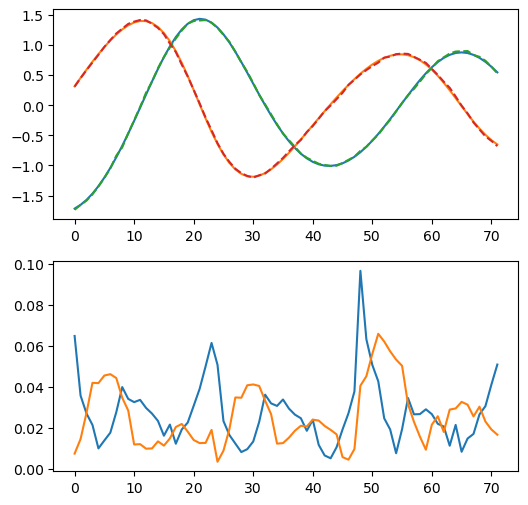

NameError: name 'tata' is not defined

In [16]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

print(tata.shape)

In [50]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.012418, valid=0.007547, test=0.006290
	validation loss decreased (inf -> 0.007547), saving model ...
	epoch 2 losses: train=0.005847, valid=0.005861, test=0.004116
	validation loss decreased (0.007547 -> 0.005861), saving model ...
	epoch 3 losses: train=0.003361, valid=0.001858, test=0.002171
	validation loss decreased (0.005861 -> 0.001858), saving model ...
	epoch 4 losses: train=0.002056, valid=0.001552, test=0.001402
	validation loss decreased (0.001858 -> 0.001552), saving model ...
	epoch 5 losses: train=0.001574, valid=0.001457, test=0.001128
	validation loss decreased (0.001552 -> 0.001457), saving model ...
	epoch 6 losses: train=0.001248, valid=0.001281, test=0.001098
	validation loss decreased (0.001457 -> 0.001281), saving model ...
	epoch 7 losses: train=0.001106, valid=0.001085, test=0.000796
	validation loss decreased (0.001281 -> 0.001085), saving model ...
	epoch 8 losses: train=0.001004, valid=0.001200, test=0.

In [51]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

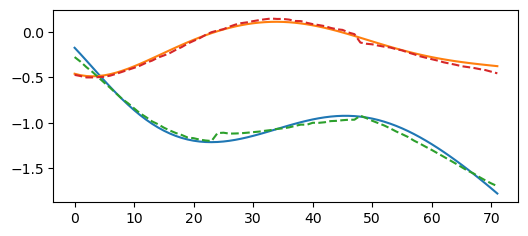

In [52]:
jdata = 25

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [56]:
model.train()
#training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.017616, valid=0.013143, test=0.017210
	validation loss decreased (inf -> 0.013143), saving model ...
	epoch 2 losses: train=0.018755, valid=0.019254, test=0.016948
	early stopping counter: 1 out of 30
	epoch 3 losses: train=0.013489, valid=0.016720, test=0.014219
	early stopping counter: 2 out of 30
	epoch 4 losses: train=0.012495, valid=0.013476, test=0.009072
	early stopping counter: 3 out of 30
	epoch 5 losses: train=0.010346, valid=0.012121, test=0.009678
	validation loss decreased (0.013143 -> 0.012121), saving model ...
	epoch 6 losses: train=0.008473, valid=0.010214, test=0.007118
	validation loss decreased (0.012121 -> 0.010214), saving model ...
	epoch 7 losses: train=0.009419, valid=0.009320, test=0.007604
	validation loss decreased (0.010214 -> 0.009320), saving model ...
	epoch 8 losses: train=0.008452, valid=0.009566, test=0.007076
	early stopping counter: 1 out of 30
	epoch 9 losses: train=0.007878, valid=0.0

In [57]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

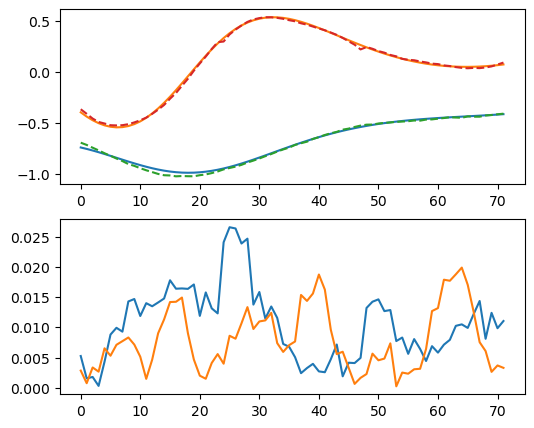

In [61]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

In [ ]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break